# DATA Practical 7 - Model Answers

Simos Gerasimou


## A Data Journey Through The Titanic

On April 15, 1912, during her maiden voyage from Southampton to New York, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg ([Wikipedia](https://en.wikipedia.org/wiki/RMS_Titanic)). As it was considered “unsinkable”, the Titanic did not carry enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

**DataVision** has been commissioned by His Majesty The King to investigate the conditions in which people survived and whether this was because of luck or whether some groups were more likely to survive than others. If discrimination due to gender or socio-economic class is identified, the Queen intends to use this information to change the cruise policies accordinly. 

#### Your tasks are to explore this dataset and generade some actionable knowledge. 


#### This Jupyter Notebook will be presented to  the House of Commons  who have limited knowledge about data science. So, your findings should be complemented by a suitable justification explaining what you observe and, when applicable, what does this observation  mean and, possibly, why it occurs.

* For each question (task) a description is provided accompanied (most of the time) by two cells: one for writing the Python code and another for providing the justification. Feel free to add more cells if you feel they are needed, but keep the cells corresponding to the same question close by.

#### Note: You are advised to use Pandas. For the visualisation, you can use Pandas, Matplotlib or Seaborn.

To answer these exercises, you should first read:

(1) Read **Chapter 3: Data Manipulation with Pandas from the Python Data Science Handbook** (https://jakevdp.github.io/PythonDataScienceHandbook/03.00-introduction-to-pandas.html)

(2) Read **Chapter 4: Visualization with Matplotlib** 
(https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html)


**Numpy API Reference**: https://numpy.org/doc/stable/reference

**Pandas API Reference**:  https://pandas.pydata.org/pandas-docs/stable/reference/index.html

**Matplotlib API Reference**: https://matplotlib.org/stable/api/index

**Seaborn API Reference**: https://seaborn.pydata.org/api.html

***

### Part 1: Reading dataset


The Titanic dataset is available on VLE (look for titanicFull.csv in the Practicals section)

Before doing the tasks below, you may want to explore the dataset using a spreadsheet editor (e.g., Excel) to get a high-level view of the dataset.

**T1) Load the Titanic dataset using Pandas**

**Note**: You have to download the dataset on your local machine and then load it onto the Jupyter Notebook

In [1]:
import pandas as pd 
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

file = "titanicFull.csv"
df = pd.read_csv(file) 

***

### Part 2: Cleaning the dataset

**T2i) Print the first 4 records of the dataset**

In [2]:
#All commands below are equivalent
df.head(4)
# df[0:4]
# df.iloc[0:4]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S


**T2ii) Print the last 6 records of the dataset**

In [3]:
#All commands below are equivalent
# df.tail(6)
# df[-6:]
df.iloc[-6:]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
1303,3,0,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C
1304,3,0,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C
1307,3,0,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C
1308,3,0,"Zimmerman, Mr. Leo",male,29.0,0,0,315082,7.8750,NaN,S


**T3) Get general info about the dataset**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   name      1309 non-null   object 
 3   sex       1309 non-null   object 
 4   age       1046 non-null   float64
 5   sibsp     1309 non-null   int64  
 6   parch     1309 non-null   int64  
 7   ticket    1309 non-null   object 
 8   fare      1308 non-null   float64
 9   cabin     295 non-null    object 
 10  embarked  1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


**T4) Explore the dataset and try to understand the meaning of each variable (column). Identify which variables are categorical and which are numerical.**

**Note**: Inferring the meaning of variables 'Pclass', 'SibSp', 'Parch' could be challenging; think of what is missing from the dataset and what types of people were travelling on the Titanic. If you find it more difficult, the answer is at the end of this notebook

In [5]:
# Answer
# - Pclass: Passenger class  (1=1st; 2=2nd; 3=3rd - Categorical - ordinal - transformed into 1,2,3))
# - Survived: Survival (0=No; 1=Yes - Categorical - nominal - transformed into 0 and 1)
# - Name: Passenger's name (Text)
# - Sex: Passenger's sex (Categorical - nominal)          
# - Age: Passenger's age (Numerical - discrete)       
# - SibSp: Number of Siblings/Spouses Aboard (Numerical - discrete)       
# - Parch: Number of Parents/Children Aboard (Numerical - discrete)       
# - Ticket: Ticket number (Text)       
# - Fare: Passenger fare (Numerical - continuous)       
# - Cabin: Cabin number (Categorical - nominal) 
# - Embarked: Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)

**T5) Get the shape of the dataframe**

In [6]:
df.shape

(1309, 11)

**T6) Get the name of the columns for the dataframe**

In [7]:
df.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked'],
      dtype='object')

**T7) Do you think the columns (variables) need to be more readable? In particular, those that you might have found difficult to understand in T4**

In [8]:
#Adding more readable names to the following variables
df.rename(index=str, columns={"pclass":"ticketClass", "sibsp":"siblingsSpouses", "parch":"parentsChildren"}, inplace=True)
df.columns

Index(['ticketClass', 'survived', 'name', 'sex', 'age', 'siblingsSpouses',
       'parentsChildren', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

**T8) Are there any duplicated records?**

In [9]:
duplicated = df.duplicated().sum()
print("There are %d duplicated records" % (duplicated))

There are 0 duplicated records


**T9) Copy the dataset so that you manipulate the copied dataset and leave the original unaffected**

**Hint**: Check the pandas documentation for help on how to copy the dataframe

In [10]:
dfCopy = df.copy()

**T10) Create a new dataframe in which**
* **a Missing variable (column) indicates the number of missing data for each variable in the titanic dataset**
* **a Percentage variable indicates the percentage of the missing data over the size of the titanic dataset**

**Print the records in this new dataframe sorted in descending order**

In [11]:
# Get the missing data and sort it in ascending order
missingDataSummary    = dfCopy.isna().sum()

# # Calculate the percentage of missing data
missingDataPercentage = (dfCopy.isnull().sum()/dfCopy.shape[0])


# #Solution1: Creating a new dataframe
missingData = pd.DataFrame(data={'Missing':missingDataSummary, 'Percentage':missingDataPercentage})

# #Solution2: concatenate the two Series as a new dataframe
missingData = pd.concat([missingDataSummary, missingDataPercentage], axis=1, keys=['Missing', 'Percentage'])


# #Display missing data sorted in descenging order of missing
missingData.sort_values(ascending=False, by='Missing')

,Missing,Percentage
cabin,1014,0.774637
age,263,0.200917
embarked,2,0.001528
fare,1,0.000764
name,0,0.000000
ticketClass,0,0.000000
survived,0,0.000000
parentsChildren,0,0.000000
siblingsSpouses,0,0.000000
sex,0,0.000000


**T11) What should we do with the variable with the highest number of missing data. Consider the amount of missing data compared to the total number of available data.**

In [12]:
# We need to drop the Cabin variable because the missing data is 77% of the total data
dfCopyClean = dfCopy.drop(columns='cabin')

dfCopyClean.isna().sum().sort_values(ascending=False)

age                263
embarked             2
fare                 1
ticketClass          0
survived             0
name                 0
siblingsSpouses      0
sex                  0
ticket               0
parentsChildren      0
dtype: int64

**T12) Impute the categorical variable(s) with the mode value**


In [13]:
dfCopyClean['embarked'] = dfCopyClean['embarked'].fillna(dfCopyClean['embarked'].mode()[0])

dfCopyClean.isna().sum().sort_values(ascending=False)

age                263
fare                 1
survived             0
ticketClass          0
sex                  0
name                 0
siblingsSpouses      0
parentsChildren      0
ticket               0
embarked             0
dtype: int64

**T13i) Plot the histogram of the numeric variable with the largest number of missing data so as to determine the best value to fill in the missing data. Add suitable title and axis names.**

**Note: You may want to use the native Pandas visualisation, matplotlib or seaborn**

**Hint**: Check the relevant section from the Python Data Science Handbook (https://jakevdp.github.io/PythonDataScienceHandbook/04.05-histograms-and-binnings.html) or the Pandas documentation (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.hist.html)

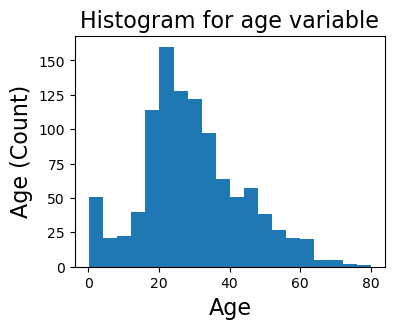

In [14]:
#Using pandas
plt.figure(figsize=(4,3), dpi=100)
ax = dfCopyClean['age'].hist(bins=20)
ax.set_title("Histogram for age variable",fontsize=16)
ax.set_xlabel('Age', fontsize=16)                  # set x label
ax.set_ylabel('Age (Count)', fontsize=16, rotation=90) # set y label
ax.grid(False)

Text(0, 0.5, 'Age (Count)')

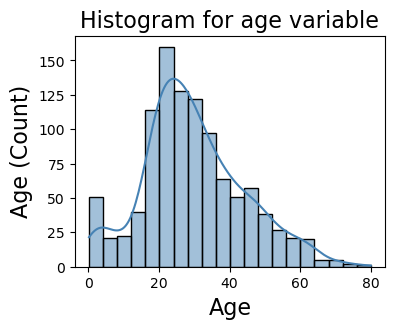

In [15]:
#Using seaborn
plt.figure(figsize=(4,3), dpi=100)
g = sns.histplot(dfCopyClean, x='age', kde=True, color='steelblue', bins=20)
g.set_title("Histogram for age variable",fontsize=16)
g.set_xlabel('Age', fontsize=16)                  # set x label
g.set_ylabel('Age (Count)', fontsize=16, rotation=90) # set y label

Text(0, 0.5, 'Age (Count)')

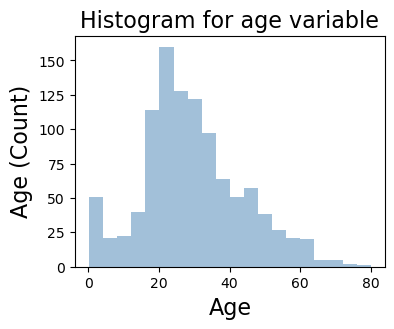

In [16]:
#Using matplotlib
plt.figure(figsize=(4,3), dpi=100)
plt.hist(dfCopyClean['age'], bins=20, alpha=0.5, density=False,
         histtype='stepfilled', color='steelblue', edgecolor='none')

plt.title("Histogram for age variable",fontsize=16)
plt.xlabel('Age',fontsize=16)                  # set x label
plt.ylabel('Age (Count)',fontsize=16,rotation=90) # set y label

**T13ii) Impute the numeric variable (just one) with an appropriate value**

* Which value you use for imputation (e.g., mean or median), report the numerical value, and why this choice is appropriate for this variable.


In [17]:
dfCopyClean['age'] = dfCopyClean['age'].fillna(dfCopyClean['age'].median())

dfCopyClean.isna().sum().sort_values(ascending=False)

fare               1
ticketClass        0
survived           0
name               0
age                0
sex                0
siblingsSpouses    0
parentsChildren    0
ticket             0
embarked           0
dtype: int64

**T13iii) Plot the histogram again for the variable from task T13 after imputation and observe how the distribution has changed.**

Text(0, 0.5, 'Age (Count))')

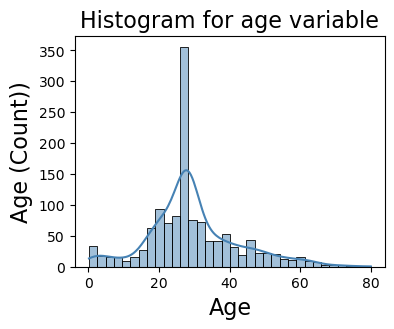

In [18]:
#Using seaborn
plt.figure(figsize=(4,3), dpi=100)
g = sns.histplot(dfCopyClean, x='age', kde=True, color='steelblue')
g.set_title("Histogram for age variable",fontsize=16)
g.set_xlabel('Age', fontsize=16)                  # set x label
g.set_ylabel('Age (Count))', fontsize=16, rotation=90) # set y label

In [19]:
dfCopyClean2 = dfCopy.drop(columns='cabin')
dfCopyClean2.isna().sum().sort_values(ascending=False)

age                263
embarked             2
fare                 1
ticketClass          0
survived             0
name                 0
siblingsSpouses      0
sex                  0
ticket               0
parentsChildren      0
dtype: int64

**T14) Choose and apply an appropriate imputation method for the missing value. State the method used, the value applied, and justify your choice.**

**Hint:** You may want to consider additional factors and use a more sophisticated imputation strategy

In [24]:
#Since the missing value is a fare, it is likely that tickets of the same class
#to represent better the distribution of fare. Thus, we can imput the missing value
#with the mean/median fare value of the tickets from class 3

#Get the ticket class, i.e., 3
ticketClass = dfCopyClean[dfCopyClean['fare'].isna()]['ticketClass']

if (len(ticketClass)>0):
  print("Ticket class: ", ticketClass.iloc[0])

  #Find the median fare of tickets from class 3
  fareMedian = dfCopyClean[dfCopyClean['ticketClass']==ticketClass.iloc[0]]['fare'].median()

  #impute the value
  dfCopyClean['fare'] = dfCopyClean['fare'].fillna(fareMedian)


#Check missing data
dfCopyClean.isna().sum().sort_values(ascending=False)

ticketClass        0
survived           0
name               0
sex                0
age                0
siblingsSpouses    0
parentsChildren    0
ticket             0
fare               0
embarked           0
dtype: int64

**T15i) Save the cleaned dataframe as a csv file with name "titanicClean.csv"**

**Hint: Check the Pandas to_csv function**

In [25]:
file = "titanicClean.csv"
dfCopyClean.to_csv(file, index=False)

**T15ii) Load the cleaned dataset into a new dataframe**

In [26]:
titanicClean = pd.read_csv(file)

***

### Part 3: Analysing the dataset

**T16) Get some descriptive statistics for the dataset selecting only the variables for which the descriptive statistics make sense**

In [27]:
#the describe function will provide descriptive statistics to any variable that is numeric
#including PassengerId and TicketClass; however, these variable do not have any meaning
#Hence, they should be included in the descriptive statistics set
titanicClean[['survived', 'age', 'siblingsSpouses', 'parentsChildren', 'fare']].describe()

,survived,age,siblingsSpouses,parentsChildren,fare
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,0.381971,29.503186,0.498854,0.385027,33.276193
std,0.486055,12.905241,1.041658,0.865560,51.743584
min,0.000000,0.170000,0.000000,0.000000,0.000000
25%,0.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,35.000000,1.000000,0.000000,31.275000
max,1.000000,80.000000,8.000000,9.000000,512.329200


**T17i) For each passenger, find out how many family members she/he has in total and store this information as a new variable in the dataframe**

In [28]:
titanicClean["familySize"] = titanicClean["siblingsSpouses"] + titanicClean["parentsChildren"] + 1


titanicClean.head()

,ticketClass,survived,name,sex,age,siblingsSpouses,parentsChildren,ticket,fare,embarked,familySize
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,S,1
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S,4
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,4
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,S,4
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,S,4


**T17ii) Print the records for the family with surname "Palsson" and confirm that the result from task T17i is correct**

In [29]:
#Select the entries whos name variable contains the string "Palsson"
titanicClean[titanicClean['name'].str.contains("Palsson")]

,ticketClass,survived,name,sex,age,siblingsSpouses,parentsChildren,ticket,fare,embarked,familySize
1096,3,0,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.075,S,5
1097,3,0,"Palsson, Master. Paul Folke",male,6.0,3,1,349909,21.075,S,5
1098,3,0,"Palsson, Miss. Stina Viola",female,3.0,3,1,349909,21.075,S,5
1099,3,0,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.075,S,5
1100,3,0,"Palsson, Mrs. Nils (Alma Cornelia Berglund)",female,29.0,0,4,349909,21.075,S,5


**T18): Find out and print the details of the biggest family on board**

**Hint: You may want to check https://en.wikipedia.org/wiki/Passengers_of_the_Titanic or https://titanicfacts.net/titanic-passenger-list**

Also read: https://en.wikipedia.org/wiki/Passengers_of_the_Titanic#Third_class

In [30]:
#Solution1
titanicClean[titanicClean['familySize']==max(titanicClean["familySize"])]

# Solution2
# biggestfamily = np.where(titanicClean["familySize"] == max(titanicClean["familySize"]))
# titanicClean.iloc[biggestfamily]

,ticketClass,survived,name,sex,age,siblingsSpouses,parentsChildren,ticket,fare,embarked,familySize
1170,3,0,"Sage, Master. Thomas Henry",male,28.0,8,2,CA. 2343,69.55,S,11
1171,3,0,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,S,11
1172,3,0,"Sage, Miss. Ada",female,28.0,8,2,CA. 2343,69.55,S,11
1173,3,0,"Sage, Miss. Constance Gladys",female,28.0,8,2,CA. 2343,69.55,S,11
1174,3,0,"Sage, Miss. Dorothy Edith ""Dolly""",female,28.0,8,2,CA. 2343,69.55,S,11
1175,3,0,"Sage, Miss. Stella Anna",female,28.0,8,2,CA. 2343,69.55,S,11
1176,3,0,"Sage, Mr. Douglas Bullen",male,28.0,8,2,CA. 2343,69.55,S,11
1177,3,0,"Sage, Mr. Frederick",male,28.0,8,2,CA. 2343,69.55,S,11
1178,3,0,"Sage, Mr. George John Jr",male,28.0,8,2,CA. 2343,69.55,S,11
1179,3,0,"Sage, Mr. John George",male,28.0,1,9,CA. 2343,69.55,S,11


**T19i) How was the ticket fare for class 1 distributed? Generate a boxplot and investigate whether there are any interesting insights**

**Hint**: You may want to check: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.boxplot.html

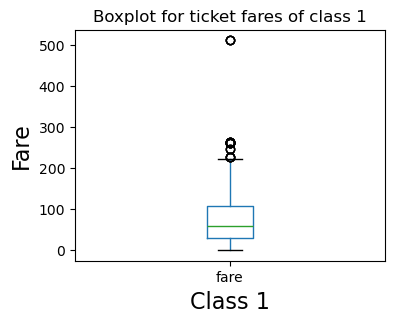

In [31]:
#Using Pandas
plt.figure(figsize=(4,3), dpi=100)
ax = titanicClean[titanicClean['ticketClass']==1].boxplot(column='fare')
ax.set_title("Boxplot for ticket fares of class 1")
ax.set_ylabel('Fare',fontsize=16,rotation=90) # set y label
ax.set_xlabel('Class 1',fontsize=16)
ax.grid(False)

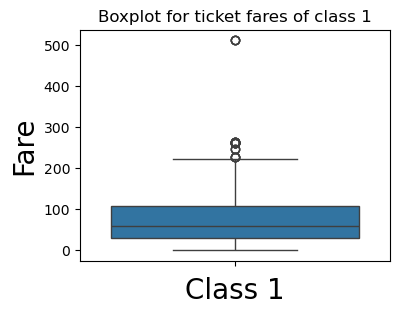

In [32]:
#Using seaborn
d = titanicClean[titanicClean['ticketClass']==1]

plt.subplots(figsize=(4,3), dpi=100)
ax = sns.boxplot(y="fare", data=d)
ax.set_title("Boxplot for ticket fares of class 1")
ax.set_ylabel('Fare',fontsize=20,rotation=90) # set y label
ax.set_xlabel('Class 1',fontsize=20) # set x label
ax.grid(False)

**T19ii) Do you see any weird fare values? Check if there are any outliers for the ticket fares of class 1 using the standard deviation method.**

In [33]:
fareClass1 = titanicClean[titanicClean['ticketClass']==1]['fare']

fareStd   = np.std(fareClass1)
fareMean  = np.mean(fareClass1) 

fareOutliers = fareClass1[(fareClass1 > fareMean + 3 *fareStd) | (fareClass1 < fareMean - 3 *fareStd)]

print("Mean=%.3f and standard deviation=%.3f of ticket fares for class 1" % (fareMean, fareStd))

print("The following could be considered as outliers \n%s" % (fareOutliers))

Mean=87.509 and standard deviation=80.323 of ticket fares for class 1
The following could be considered as outliers 
49     512.3292
50     512.3292
183    512.3292
302    512.3292
Name: fare, dtype: float64


**T19iii) Print the information for those passengers**

You can read the interesting story of the passengers and their families at:
- https://www.encyclopedia-titanica.org/titanic-survivor/charlotte-cardeza.html
- https://www.encyclopedia-titanica.org/titanic-survivor/annie-moore-ward.html


In [34]:
#Solution1
titanicClean[titanicClean['fare']==fareOutliers.iloc[0]]

#Solution2
# titanicClean.loc[fareOutliers.index]

,ticketClass,survived,name,sex,age,siblingsSpouses,parentsChildren,ticket,fare,embarked,familySize
49,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C,2
50,1,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,C,2
183,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C,1
302,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C,1


**T20) Given that Titanic stopped in three ports (C = Cherbourg, Q = Queenstown, S = Southampton) before departing from the UK, can we identify any patterns regarding the ports at which passengers embarked on the Titanic? Produce a bar plot to illustrate this**

**Hint:** You may want to check: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html

<Figure size 400x300 with 0 Axes>

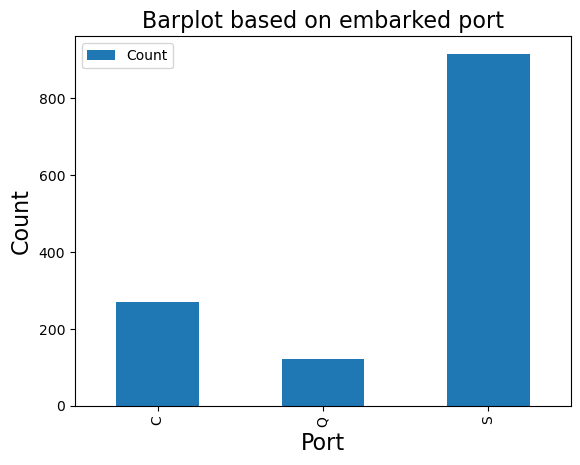

In [35]:
#Using Pandas

#We first need to group the dataframe based on the embarked variable
embarked = titanicClean.groupby('embarked').count()

#Then, we create another dataframe based on the grouping
embarkedDf = pd.DataFrame({'Port': embarked.index, 'Count':embarked['ticketClass']})

#Finally, we plot the barplot
plt.figure(figsize=(4,3), dpi=100)
ax = embarkedDf.plot.bar(x='Port', y='Count')
ax.set_title("Barplot based on embarked port", fontsize=16)
ax.set_ylabel('Count',fontsize=16,rotation=90) # set y label
ax.set_xlabel('Port', fontsize=16)
ax.grid(False)

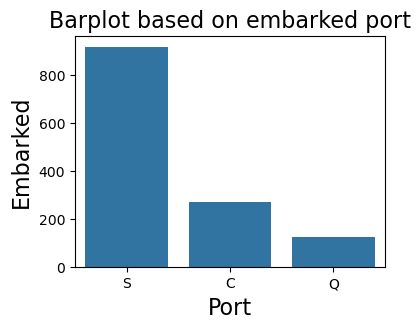

In [36]:
#Using seaborn
plt.subplots(figsize=(4,3), dpi=100)
ax = sns.countplot(data=titanicClean, x='embarked')
ax.set_title("Barplot based on embarked port", fontsize=16)
ax.set_xlabel('Port',fontsize=16) # set x label
ax.set_ylabel('Embarked',fontsize=16,rotation=90) # set y label
ax.grid(False)

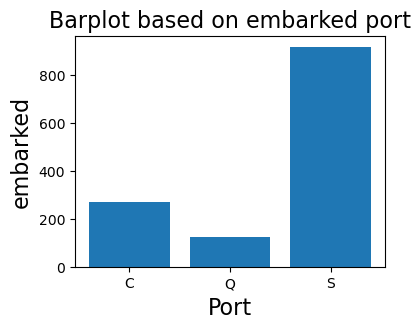

In [37]:
#Using matplotlib

#We first need to group data items together
#all entries in the resulting dataframe count the number of passengers embarked on each port
# embarked = titanicClean.groupby('embarked').count().iloc[:,1] 
embarked = titanicClean.groupby('embarked').count()['ticketClass']

plt.figure(figsize=(4,3), dpi=100)

plt.bar(embarked.index, embarked)
plt.title("Barplot based on embarked port", fontsize=16)
plt.xlabel('Port',fontsize=16) # set x label
plt.ylabel('embarked',fontsize=16,rotation=90) # set y label
ax.grid(False)

**T21) Was there any bias in those survived based on their ticket class? Produce a grouped barplot to demonstrate the difference between those who survived and those who did not based on ticket class. What do you observe?**


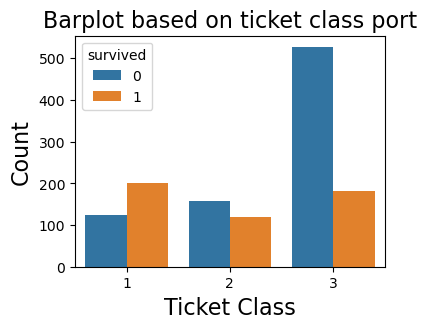

In [38]:
#Using seaborn
plt.subplots(figsize=(4,3), dpi=100)
ax = sns.countplot(data=titanicClean, x='ticketClass', hue="survived")
ax.set_title("Barplot based on ticket class port", fontsize=16)
ax.set_xlabel('Ticket Class',fontsize=16) # set x label
ax.set_ylabel('Count',fontsize=16,rotation=90) # set y label
ax.grid(False)

## Brain Teaser

In [39]:
#to enable rerunning the code
if "Title" in titanicClean.columns.to_list():
    titanicClean = titanicClean.drop(columns='Title', axis=1)

#insert column in position 2 (before the name column)
titanicClean.insert(loc=2, column='Title', value=titanicClean.name.str.extract(' ([A-Za-z]+)\.', expand=False))

titanicClean['Title'] = titanicClean['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
            'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

titanicClean['Title'] = titanicClean['Title'].replace('Mlle', 'Miss')
titanicClean['Title'] = titanicClean['Title'].replace('Ms', 'Miss')
titanicClean['Title'] = titanicClean['Title'].replace('Mme', 'Mrs')

titanicClean

,ticketClass,survived,Title,name,sex,age,siblingsSpouses,parentsChildren,ticket,fare,embarked,familySize
0,1,1,Miss,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,S,1
1,1,1,Master,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S,4
2,1,0,Miss,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,4
3,1,0,Mr,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,S,4
4,1,0,Mrs,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,S,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,Miss,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,C,2
1305,3,0,Miss,"Zabour, Miss. Thamine",female,28.00,1,0,2665,14.4542,C,2
1306,3,0,Mr,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,C,1
1307,3,0,Mr,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,C,1


**BT2) Using the outcome of BT1, print the percentage of survived passengers based on their title**

In [41]:
titanicClean[['Title', 'survived']].groupby(['Title']).agg({"survived":"sum"})\
.sort_values(by="survived", ascending=False)\
[["survived"]].apply(lambda x: 100*x/x.sum())\
#

,survived
Title,
Miss,35.8
Mrs,31.2
Mr,24.6
Master,6.2
Rare,2.2


In [37]:
# Answers to T4
# - Pclass     Ticket class	     
# - SibSp      # of siblings/spouses aboard the Titanic
# - Parch      # of parents / children aboard the Titanic